# Exploración del catálogo SDSS DR17
### Práctica de Big Data de la Institución Universitaria de Envigado

**Integrantes:** Natalia Flores Pérez, Santiago Arcila Gutiérrez, Alejandro Restrepo Uribe y Antonio Patiño Montoya



Este cuaderno acompaña al pipeline, sirve para dos cosas:

1. Entender los datos de partida antes de que el pipeline los procese.
2. Ver de cerca la evaluación perezosa de Dask, que es el concepto que más
   cuesta al principio y que se aprecia mejor de forma interactiva.

El pipeline completo se ejecuta con python src/run_pipeline.py este cuaderno
no lo reemplaza, lo complementa

In [1]:
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

from config import CSV_SDSS, DIR_EPOCAS, DIR_PARQUET, BANDAS, CENTINELA
print("Catálogo:", CSV_SDSS)

Catálogo: /home/claude/proyecto/data/raw/star_classification.csv


## 1. El catálogo real de partida

In [2]:
sdss = pd.read_csv(CSV_SDSS)
print(f"Objetos: {sdss.shape[0]:,}   Columnas: {sdss.shape[1]}")
sdss.head()

Objetos: 100,000   Columnas: 18


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [3]:
# Qué contiene cada columna
resumen = pd.DataFrame({
    "tipo": [str(t) for t in sdss.dtypes],
    "nulos": sdss.isna().sum().values,
    "únicos": [sdss[c].nunique() for c in sdss.columns],
    "mínimo": [sdss[c].min() if pd.api.types.is_numeric_dtype(sdss[c]) else "-"
               for c in sdss.columns],
    "máximo": [sdss[c].max() if pd.api.types.is_numeric_dtype(sdss[c]) else "-"
               for c in sdss.columns],
})
resumen

,tipo,nulos,únicos,mínimo,máximo
0,float64,0,78053,1237645942904389888.0,1237680531356386304.0
1,float64,0,99999,0.005528,359.99981
2,float64,0,99999,-18.785328,83.000519
3,float64,0,93748,-9999.0,32.78139
4,float64,0,92651,-9999.0,31.60224
5,float64,0,91901,9.82207,29.57186
6,float64,0,92019,9.469903,32.14147
7,float64,0,92007,-9999.0,29.38374
8,int64,0,430,109,8162
9,int64,0,1,301,301


### El problema de los centinelas

El archivo no tiene ningún nulo declarado, pero eso es engañoso, las mediciones
que no se pudieron hacer están marcadas con **−9999**, que es un valor numérico
perfectamente válido para pandas, si no se detecta cualquier promedio queda
destruido.

In [4]:
for banda in BANDAS:
    n = (sdss[banda] <= CENTINELA + 1).sum()
    print(f"  banda {banda}: {n} centinelas")

print("\nEfecto sobre la media de la banda u:")
print(f"  con centinelas : {sdss['u'].mean():>12.3f}")
print(f"  sin centinelas : {sdss.loc[sdss['u'] > CENTINELA + 1, 'u'].mean():>12.3f}")

  banda u: 1 centinelas
  banda g: 1 centinelas
  banda r: 0 centinelas
  banda i: 0 centinelas
  banda z: 1 centinelas

Efecto sobre la media de la banda u:
  con centinelas :       21.980
  sin centinelas :       22.081


## 2. Las tres clases espectrales

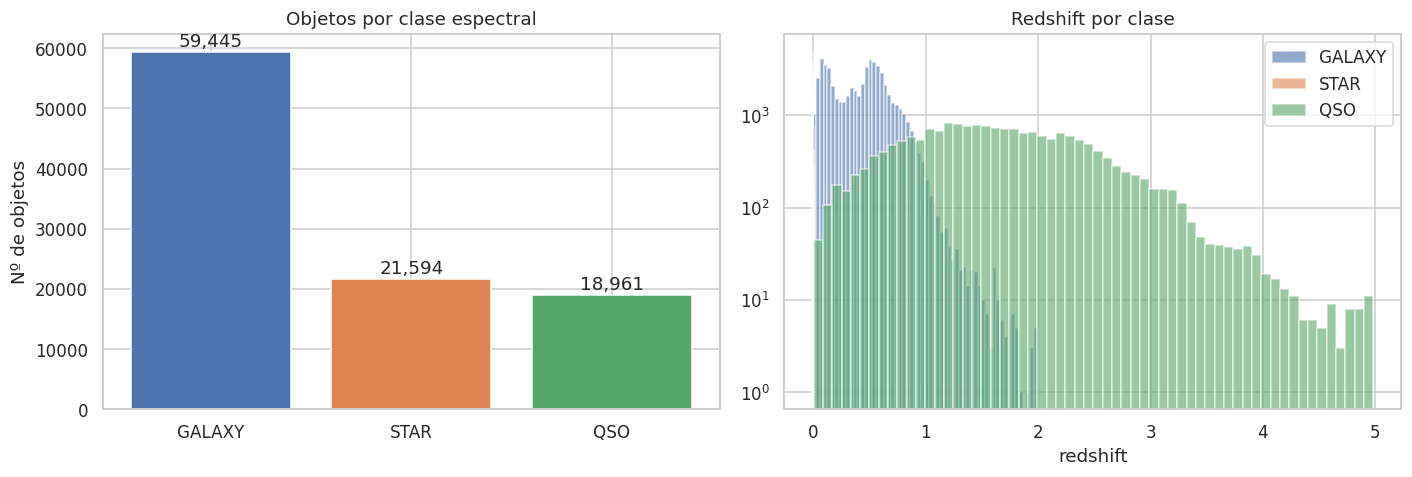

In [5]:
conteo = sdss["class"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(conteo.index, conteo.values, color=["#4C72B0", "#DD8452", "#55A868"])
ax[0].set(title="Objetos por clase espectral", ylabel="Nº de objetos")
for i, v in enumerate(conteo.values):
    ax[0].text(i, v + 900, f"{v:,}", ha="center")

limpio = sdss[(sdss["redshift"] > -0.01) & (sdss["redshift"] < 5)]
for clase, color in zip(["GALAXY", "STAR", "QSO"], ["#4C72B0", "#DD8452", "#55A868"]):
    sub = limpio[limpio["class"] == clase]["redshift"]
    ax[1].hist(sub, bins=60, alpha=0.6, label=clase, color=color)
ax[1].set(title="Redshift por clase", xlabel="redshift", yscale="log")
ax[1].legend()
plt.tight_layout(); plt.show()

Las estrellas se apilan en redshift cero porque están en nuestra propia galaxia.
Las galaxias ocupan el rango intermedio y los cuásares llegan mucho más lejos.
Esa separación es lo que hace que el redshift sea la variable más predictiva del
modelo de MLlib.

## 3. Índices de color: la variable derivada clave

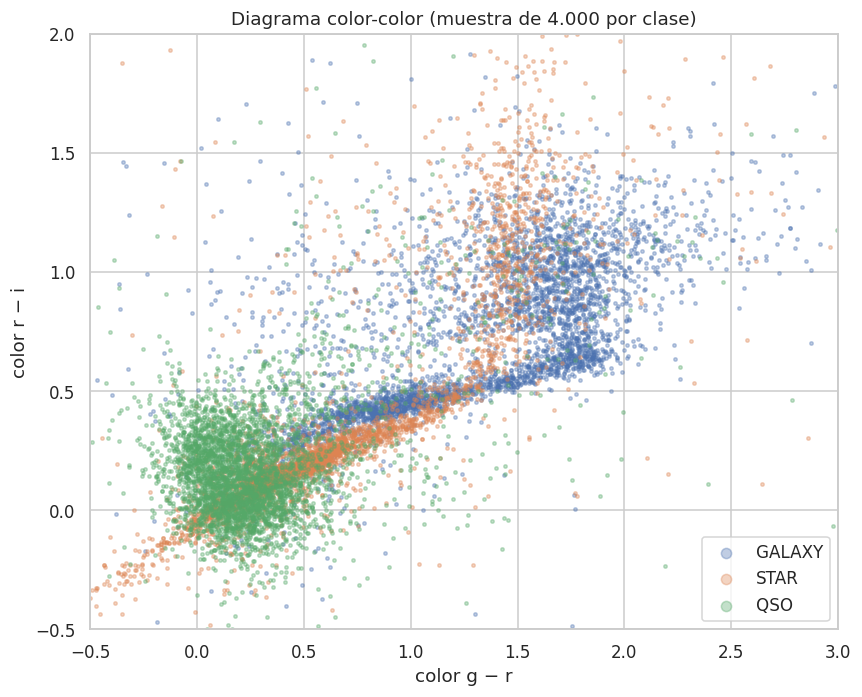

In [6]:
# Los colores son diferencias entre bandas. Miden la pendiente del espectro.
val = sdss[(sdss[BANDAS] > CENTINELA + 1).all(axis=1)].copy()
val["color_ug"] = val["u"] - val["g"]
val["color_gr"] = val["g"] - val["r"]
val["color_ri"] = val["r"] - val["i"]

fig, ax = plt.subplots(figsize=(8, 6.5))
for clase, color in zip(["GALAXY", "STAR", "QSO"], ["#4C72B0", "#DD8452", "#55A868"]):
    sub = val[val["class"] == clase].sample(min(4000, (val["class"] == clase).sum()),
                                            random_state=42)
    ax.scatter(sub["color_gr"], sub["color_ri"], s=5, alpha=0.35, label=clase, color=color)
ax.set(xlim=(-0.5, 3), ylim=(-0.5, 2), xlabel="color g − r", ylabel="color r − i",
       title="Diagrama color-color (muestra de 4.000 por clase)")
ax.legend(markerscale=3)
plt.tight_layout(); plt.show()

Cada clase ocupa su propia región, esa separación es la razón por la que
calculamos los cuatro índices de color en la etapa de Dask: son las variables que
después permiten al modelo distinguir galaxias de cuásares

## 4. Evaluación perezosa de Dask, en vivo

Esta es la parte que conviene ver de forma interactiva, requiere que ya se haya
ejecutado python src/run_pipeline.py solo 0 para que existan los CSV por época

In [7]:
import dask.dataframe as dd

archivos = sorted(DIR_EPOCAS.glob("*.csv"))
if not archivos:
    print("Faltan los CSV por época. Ejecutar: python src/run_pipeline.py --solo 0")
else:
    tam = sum(f.stat().st_size for f in archivos) / 1e6
    print(f"{len(archivos)} archivos, {tam:,.0f} MB en total")

    t0 = time.time()
    ddf = dd.read_csv(str(DIR_EPOCAS / "epoca_*.csv"), blocksize="32MB")
    print(f"\nread_csv tardó {time.time()-t0:.4f} s")
    print("...porque NO leyó nada. Solo construyó el plan.")
    print(f"Particiones: {ddf.npartitions}")

30 archivos, 553 MB en total

read_csv tardó 0.0118 s
...porque NO leyó nada. Solo construyó el plan.
Particiones: 30


In [8]:
t0 = time.time()
n = len(ddf)
print(f"len() tardó {time.time()-t0:.1f} s  ->  {n:,} filas")
print("Aquí sí leyó los archivos de verdad.")

len() tardó 4.1 s  ->  3,000,000 filas
Aquí sí leyó los archivos de verdad.


In [9]:
# Encadenar operaciones tampoco ejecuta nada
t0 = time.time()
plan = (ddf[ddf["redshift"] > 0]
        .assign(color_gr=ddf["g"] - ddf["r"])
        .groupby("class")
        .agg({"redshift": "mean", "color_gr": "mean"}))
print(f"Construir toda la cadena: {time.time()-t0:.4f} s")

t0 = time.time()
resultado = plan.compute()
print(f"compute(): {time.time()-t0:.1f} s")
resultado

Construir toda la cadena: 0.0121 s


compute(): 4.2 s


,redshift,color_gr
class,,
GALAXY,0.424842,0.590996
QSO,1.719676,-0.474404
STAR,0.000250,2.587928


## 5. La ventaja de Parquet

In [10]:
if DIR_PARQUET.exists():
    tam_csv = sum(f.stat().st_size for f in DIR_EPOCAS.glob("*.csv")) / 1e6
    tam_pq = sum(f.stat().st_size for f in DIR_PARQUET.rglob("*.parquet")) / 1e6
    print(f"CSV     : {tam_csv:,.0f} MB")
    print(f"Parquet : {tam_pq:,.0f} MB  ({(1-tam_pq/tam_csv)*100:.0f}% menos)")

    # UN HALLAZGO INESPERADO DEL DESARROLLO
    # -------------------------------------
    # La primera medicion dio que CSV era MAS RAPIDO que Parquet, lo contrario
    # de lo esperado. La causa: particionar por region genera un archivo por
    # cada combinacion de region y particion de entrada, o sea 45 x 30 = 1.350
    # archivos de unos 100 KB. Cada archivo tiene un costo fijo de apertura y de
    # lectura de metadatos, asi que un escaneo completo se vuelve lento.
    #
    # Es el "problema de los archivos pequenos", conocido en Big Data. Por eso
    # el pipeline escribe tambien una version compacta, en 8 archivos grandes.
    from config import DIR_INTERIM
    DIR_COMPACTO = DIR_INTERIM / "catalogo_parquet_compacto"

    n_part = len(list(DIR_PARQUET.rglob("*.parquet")))
    n_comp = len(list(DIR_COMPACTO.rglob("*.parquet"))) if DIR_COMPACTO.exists() else 0
    print(f"\nParquet particionado por region: {n_part} archivos")
    print(f"Parquet compacto               : {n_comp} archivos")

    _ = dd.read_parquet(str(DIR_PARQUET))["redshift"].mean().compute()   # calentamiento

    def medir(fn, veces=2):
        ts = []
        for _ in range(veces):
            t0 = time.time(); fn(); ts.append(time.time() - t0)
        return min(ts)

    t_csv  = medir(lambda: dd.read_csv(str(DIR_EPOCAS / "epoca_*.csv"),
                                       usecols=["redshift"])["redshift"].mean().compute(), 1)
    t_part = medir(lambda: dd.read_parquet(str(DIR_PARQUET))["redshift"].mean().compute())
    t_comp = medir(lambda: dd.read_parquet(str(DIR_COMPACTO))["redshift"].mean().compute())

    print(f"\nEscaneo completo (media del redshift sobre 3 M de filas):")
    print(f"  CSV (30 archivos)            : {t_csv:6.2f} s")
    print(f"  Parquet particionado ({n_part:>4}) : {t_part:6.2f} s")
    print(f"  Parquet compacto ({n_comp:>4})     : {t_comp:6.2f} s")

    print(f"\nLECTURA: el Parquet compacto es {t_part/t_comp:.1f}x mas rapido que el")
    print("particionado para un escaneo completo. Pero el particionado sigue")
    print("siendo el correcto para consultas FILTRADAS por region, porque el")
    print("motor puede saltarse los archivos que no necesita. No hay un formato")
    print("mejor en abstracto: depende de como se vayan a consultar los datos.")
else:
    print("Falta el Parquet. Ejecutar: python src/run_pipeline.py --solo 0 1")

CSV     : 553 MB
Parquet : 414 MB  (25% menos)

Parquet particionado por region: 1350 archivos
Parquet compacto               : 8 archivos



Escaneo completo (media del redshift sobre 3 M de filas):
  CSV (30 archivos)            :   2.46 s
  Parquet particionado (1350) :   3.22 s
  Parquet compacto (   8)     :   0.05 s

LECTURA: el Parquet compacto es 70.2x mas rapido que el
particionado para un escaneo completo. Pero el particionado sigue
siendo el correcto para consultas FILTRADAS por region, porque el
motor puede saltarse los archivos que no necesita. No hay un formato
mejor en abstracto: depende de como se vayan a consultar los datos.


---

## Qué sigue

El pipeline completo está en src/ para ejecutarlo:

```bash
python src/run_pipeline.py                  # todo, escala grande
ESCALA=pequena python src/run_pipeline.py   # prueba rápida
```

Los resultados quedan en outputs/metricas/ y outputs/figuras/, y el análisis
está en `INFORME.md`.